# XRAY component separation: plots

Choose `MAP_SIZE` and which recovered map to load (`RECOVERED_KIND`), then plot:
- eROSITA data
- one Poisson noise realization
- recovered signal

At the bottom, a high-resolution single-map plot is saved to disk.


In [136]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import cmocean

ROOT = Path.cwd().resolve()
ROOT

# Optional: Gaussian smoothing for visualization
try:
    from scipy.ndimage import gaussian_filter
except Exception:
    gaussian_filter = None


In [137]:
# ----
# Select map size and which recovered map to load
# ----

MAP_SIZE_RAW = 512  # set to 1024 if needed
RECOVERED_KIND = 'lin'  # 'pos' or 'lin' (or 'auto')

if MAP_SIZE_RAW not in (512, 1024):
    raise ValueError(f'MAP_SIZE_RAW must be 512 or 1024, got {MAP_SIZE_RAW}')

if RECOVERED_KIND not in ('pos', 'lin', 'auto'):
    raise ValueError(f"RECOVERED_KIND must be 'pos', 'lin', or 'auto', got {RECOVERED_KIND}")

# Analysis map size (may be changed after loading the recovered map)
MAP_SIZE = MAP_SIZE_RAW

# When downsampling larger maps to match a smaller recovered map, optionally pre-smooth to reduce aliasing.
DOWNSAMPLE_SIGMA = 0.8 if gaussian_filter is not None else None

def downsample_by_four(image, sigma=None):
    """
    Downsamples a NumPy image by optionally applying a Gaussian filter and averaging
    over non-overlapping 2x2 pixel blocks.

    Args:
        image (np.ndarray): Input image of shape (H, W) for grayscale 
                            or (H, W, C) for color.
        sigma (float | None): If provided, apply a Gaussian filter with this sigma
                              before downsampling. For color images, filtering is
                              applied per-channel (no channel mixing).

    Returns:
        np.ndarray: Downsampled image of shape (H/2, W/2) for grayscale 
                    or (H/2, W/2, C) for color.
    """
    H, W = image.shape[:2]

    # Ensure image dimensions are even
    if H % 2 != 0 or W % 2 != 0:
        raise ValueError("Image dimensions must be even for 2x2 downsampling.")

    if sigma is not None:
        if gaussian_filter is None:
            raise ImportError('scipy is required for gaussian_filter-based downsampling')
        if image.ndim == 2:
            image = gaussian_filter(image, sigma=float(sigma))
        elif image.ndim == 3:
            image = gaussian_filter(image, sigma=(float(sigma), float(sigma), 0.0))
        else:
            raise ValueError("Unsupported image shape. Must be 2D (grayscale) or 3D (color).")

    # Downsample by averaging over 2x2 blocks
    if image.ndim == 2:  # Grayscale
        return image.reshape(H//2, 2, W//2, 2).mean(axis=(1, 3))

    elif image.ndim == 3:  # Color (H, W, C)
        return image.reshape(H//2, 2, W//2, 2, image.shape[2]).mean(axis=(1, 3))

    else:
        raise ValueError("Unsupported image shape. Must be 2D (grayscale) or 3D (color).")

def downsample_to_shape(image: np.ndarray, target_hw: tuple[int, int], sigma=None) -> np.ndarray:
    out = np.asarray(image)
    th, tw = map(int, target_hw)
    while out.shape[0] > th or out.shape[1] > tw:
        if out.shape[0] // 2 < th or out.shape[1] // 2 < tw:
            raise ValueError(f'Cannot downsample from {out.shape[:2]} to {target_hw}')
        out = downsample_by_four(out, sigma=sigma)
    if out.shape[:2] != (th, tw):
        raise ValueError(f'Downsampled to {out.shape[:2]}, expected {target_hw}')
    return out

MAP_SIZE_RAW, MAP_SIZE, RECOVERED_KIND


(512, 512, 'lin')

In [138]:
# ----
# Load recovered signal
# ----

filename = "recovered_signal_XRays_size512_dcfft_wtypeBump-Steerable_lpos10_lnoise0_mstep1_batch25_micro10_optNyq0_postNyq0"  # without .npy is fine
# filename = 'recovered_signal_XRays_size512_dcfft_wtypeBump-Steerable_lpos10_lnoise10_mstep1_batch25_micro10_optNyq0_postNyq0'
# filename = "size512_dcfft_wtypeBump-Steerable_lpos10_lnoise0_optNyq0_postNyq0_micro15.npy"  # without .npy is fine
# filename = 'recovered_signal_XRays_512_(lambda).npy'

recovered_path = ROOT / "results_new" / (
    filename if filename.endswith('.npy') else f"{filename}.npy"
)
if not recovered_path.exists():
    raise FileNotFoundError(f"Recovered file not found: {recovered_path}")

recovered = np.asarray(np.load(recovered_path)).squeeze()
if recovered.ndim == 3 and recovered.shape[0] in (1, 2, 3):
    recovered = recovered[0]
recovered = np.asarray(recovered).squeeze()

if recovered.ndim != 2 or recovered.shape[0] != recovered.shape[1]:
    raise ValueError(f"Expected a square 2D recovered map, got shape {recovered.shape}")

TARGET_SHAPE = (int(recovered.shape[0]), int(recovered.shape[1]))
if TARGET_SHAPE != (MAP_SIZE_RAW, MAP_SIZE_RAW):
    print(
        f"Recovered map has shape {TARGET_SHAPE}, expected {(MAP_SIZE_RAW, MAP_SIZE_RAW)}; downsampling other maps to match."
    )

MAP_SIZE = TARGET_SHAPE[0]
recovered_path, recovered.shape, recovered.dtype


(PosixPath('/Users/tsouros/Desktop/Projects/STL-Dev/X-ray project/results_new/recovered_signal_XRays_size512_dcfft_wtypeBump-Steerable_lpos10_lnoise0_mstep1_batch25_micro10_optNyq0_postNyq0.npy'),
 (512, 512),
 dtype('float64'))

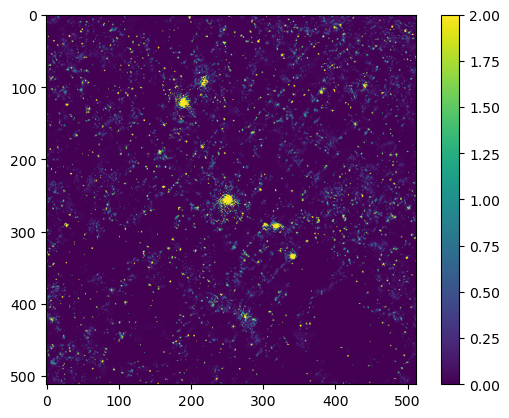

In [139]:
plt.imshow(recovered, vmin=0, vmax=2)
plt.colorbar()

In [140]:
# ----
# Load eROSITA coadd map (MAP_SIZE x MAP_SIZE)
# Prefer cached .npy if present; otherwise read FITS (requires astropy).
# ----

fits_path = ROOT / 'x-ray data' / f'eROSITA_coadd_LANCZOS3_img_{MAP_SIZE_RAW}_8deg.fits'
npy_path = fits_path.with_suffix('.npy')

if npy_path.exists():
    data = np.load(npy_path)
else:
    from astropy.io import fits
    data = fits.getdata(fits_path)

data = np.asarray(data).squeeze()
if data.shape != TARGET_SHAPE:
    data = downsample_to_shape(data, TARGET_SHAPE, sigma=DOWNSAMPLE_SIGMA)

fits_path, data.shape, data.dtype, float(np.nanmin(data)), float(np.nanmax(data))


(PosixPath('/Users/tsouros/Desktop/Projects/STL-Dev/X-ray project/x-ray data/eROSITA_coadd_LANCZOS3_img_512_8deg.fits'),
 (512, 512),
 dtype('>f4'),
 -1.9297155141830444,
 268.37103271484375)

In [141]:
# ----
# Optional: project recovered map so that the implied noise (data - recovered) is integer-valued
# ----

APPLY_NOISE_INTEGER_PROJECTION = False
NOISE_INT_DELTA = None  # e.g. 0.25 to only snap when already close to an integer; None snaps all pixels
CLAMP_NOISE_NONNEG = False

recovered_raw = np.asarray(recovered, dtype=np.float64)
noise_hat = np.asarray(data - recovered_raw, dtype=np.float64)
noise_round = np.rint(noise_hat)
if CLAMP_NOISE_NONNEG:
    noise_round = np.maximum(noise_round, 0.0)

if NOISE_INT_DELTA is None:
    noise_int = noise_round
else:
    close = np.abs(noise_hat - noise_round) <= float(NOISE_INT_DELTA)
    noise_int = np.where(close, noise_round, noise_hat)

recovered_int = np.asarray(data - noise_int, dtype=np.float64)

# If enabled, overwrite `recovered` so the rest of the notebook uses the projected map.
if APPLY_NOISE_INTEGER_PROJECTION:
    recovered = recovered_int

print('Integer projection enabled:', APPLY_NOISE_INTEGER_PROJECTION)
print('Residual (data - recovered) integer everywhere:', np.allclose((data - recovered), np.rint(data - recovered)))
print('Delta recovered RMS:', float(np.std(recovered - recovered_raw)))


Integer projection enabled: False
Residual (data - recovered) integer everywhere: False
Delta recovered RMS: 0.0


In [142]:
# ----
# Load one Poisson noise realization (MAP_SIZE x MAP_SIZE)
# ----

noise_dir = ROOT / 'x-ray data' / str(MAP_SIZE_RAW)
noise_files = sorted(noise_dir.glob(f'poisson_image_{MAP_SIZE_RAW}_*.npy'))
if not noise_files:
    raise FileNotFoundError(f'No noise files found in {noise_dir}')

noise_path = noise_files[0]
noise = np.load(noise_path)
noise = np.asarray(noise).squeeze()
if noise.shape != TARGET_SHAPE:
    noise = downsample_to_shape(noise, TARGET_SHAPE, sigma=DOWNSAMPLE_SIGMA)

noise_path.name, noise.shape, noise.dtype, float(np.nanmin(noise)), float(np.nanmax(noise))


('poisson_image_512_000.npy', (512, 512), dtype('int64'), 0.0, 6.0)

In [143]:
# ----
# Diagnostics: do we reach the noise floor at small scales?
# (No filtering/windowing/mean-subtraction; just summary stats + raw high-k bandpower checks.)
# ----

# Pixel-space sanity: compare overall RMS levels
data_rms = float(np.std(np.asarray(data, dtype=np.float64)))
noise_rms = float(np.std(np.asarray(noise, dtype=np.float64)))
print(f'data RMS:  {data_rms:.6g}')
print(f'noise RMS (one realisation): {noise_rms:.6g}')
print(f'RMS ratio (noise/data): {noise_rms / data_rms if data_rms > 0 else np.nan:.6g}')

# Noise ensemble RMS distribution
noise_dir = ROOT / 'x-ray data' / str(MAP_SIZE_RAW)
noise_files = sorted(noise_dir.glob(f'poisson_image_{MAP_SIZE_RAW}_*.npy'))
if not noise_files:
    raise FileNotFoundError(f'No noise files found in {noise_dir}')

noise_rms_all = []
for nf in noise_files:
    n = np.asarray(np.load(nf), dtype=np.float64).squeeze()
    if n.shape != TARGET_SHAPE:
        try:
            n = downsample_to_shape(n, TARGET_SHAPE, sigma=DOWNSAMPLE_SIGMA)
        except Exception:
            continue
    noise_rms_all.append(np.std(n))
noise_rms_all = np.asarray(noise_rms_all, dtype=np.float64)
print(f'noise RMS over {len(noise_rms_all)} maps: mean={noise_rms_all.mean():.6g}, std={noise_rms_all.std():.6g}')

print('Expectation:')
print('- If the noise bank matches the noise present in the data, then at sufficiently large k,')
print('  the signal becomes negligible and P_data(k) should approach the noise level.')
print('- In that case, the high-k bandpower of the data should be ~ within 1σ of the noise ensemble mean.')
print('- If data high-k >> noise: extra small-scale structure (or mismatch in noise amplitude/PSF).')
print('- If data high-k << noise: data is effectively less noisy (coadd) or noise bank is too strong.')

# High-k bandpower comparison (raw spectra)
# Define the raw spectrum helper here so this cell is runnable standalone.
try:
    from scipy import stats
except Exception as exc:
    raise ImportError('scipy is required for radial binning (stats.binned_statistic)') from exc

PATCH_SIZE_DEG = 8.0
ELL_BINS = 60

npix = int(MAP_SIZE)
ps_rad = np.radians(PATCH_SIZE_DEG)
delta_theta = ps_rad / npix


def _bin_radial_raw(ps2d: np.ndarray):
    kx = np.fft.fftfreq(npix, d=delta_theta)
    ky = np.fft.fftfreq(npix, d=delta_theta)
    kxx, kyy = np.meshgrid(kx, ky)
    k = (2 * np.pi * np.sqrt(kxx**2 + kyy**2)).flatten()
    ps1d = np.asarray(ps2d, dtype=np.float64).flatten()

    k_bins = np.linspace(0, np.max(k), ELL_BINS + 1)
    pk_flat, _, _ = stats.binned_statistic(k, ps1d, bins=k_bins, statistic='mean')
    k_centers = 0.5 * (k_bins[1:] + k_bins[:-1])
    return pk_flat, k_centers


def powers_auto_raw(a: np.ndarray):
    m = np.asarray(a, dtype=np.float64)
    fft_m = np.fft.fft2(m, norm=None)
    ps2d = np.abs(fft_m * np.conj(fft_m)) * (delta_theta**2) / (npix**2)
    return _bin_radial_raw(ps2d)


pk_data_raw, k_raw = powers_auto_raw(data)

# Compute raw spectra for all noise maps (can take a minute for MAP_SIZE=1024)
pk_noise_all = []
for nf in noise_files:
    n = np.asarray(np.load(nf), dtype=np.float64).squeeze()
    if n.shape != TARGET_SHAPE:
        try:
            n = downsample_to_shape(n, TARGET_SHAPE, sigma=DOWNSAMPLE_SIGMA)
        except Exception:
            continue
    pk_n, _ = powers_auto_raw(n)
    pk_noise_all.append(pk_n)
pk_noise_all = np.asarray(pk_noise_all, dtype=np.float64)

# Define a "high-k" region: last 20% of bins
nbins = pk_data_raw.shape[0]
high_slice = slice(int(0.8 * nbins), nbins)

pkd_hi = np.asarray(pk_data_raw[high_slice], dtype=np.float64)
pkn_hi_all = np.asarray(pk_noise_all[:, high_slice], dtype=np.float64)

# Reduce: mean over bins (per realisation), then compute ensemble mean/std
pkn_hi_permap = np.nanmean(pkn_hi_all, axis=1)

pkd_hi_mean = float(np.nanmean(pkd_hi))
pkn_hi_mean = float(np.nanmean(pkn_hi_permap))
pkn_hi_std = float(np.nanstd(pkn_hi_permap))

print('High-k bandpower (raw; mean over last 20% bins):')
print(f'  data:  {pkd_hi_mean:.6g}')
print(f'  noise: {pkn_hi_mean:.6g} ± {pkn_hi_std:.6g} (1σ over noise maps)')
print(f'  ratio data/noise_mean: {pkd_hi_mean / pkn_hi_mean if pkn_hi_mean > 0 else np.nan:.6g}')

z = (pkd_hi_mean - pkn_hi_mean) / (pkn_hi_std if pkn_hi_std > 0 else np.nan)
print(f'  z = (data - noise_mean)/noise_std: {z:.3f}')

data RMS:  1.28248
noise RMS (one realisation): 0.647372
RMS ratio (noise/data): 0.504782
noise RMS over 100 maps: mean=0.646107, std=0.00130666
Expectation:
- If the noise bank matches the noise present in the data, then at sufficiently large k,
  the signal becomes negligible and P_data(k) should approach the noise level.
- In that case, the high-k bandpower of the data should be ~ within 1σ of the noise ensemble mean.
- If data high-k >> noise: extra small-scale structure (or mismatch in noise amplitude/PSF).
- If data high-k << noise: data is effectively less noisy (coadd) or noise bank is too strong.
High-k bandpower (raw; mean over last 20% bins):
  data:  6.07744e-08
  noise: 3.10564e-08 ± 4.77389e-10 (1σ over noise maps)
  ratio data/noise_mean: 1.95691
  z = (data - noise_mean)/noise_std: 62.251


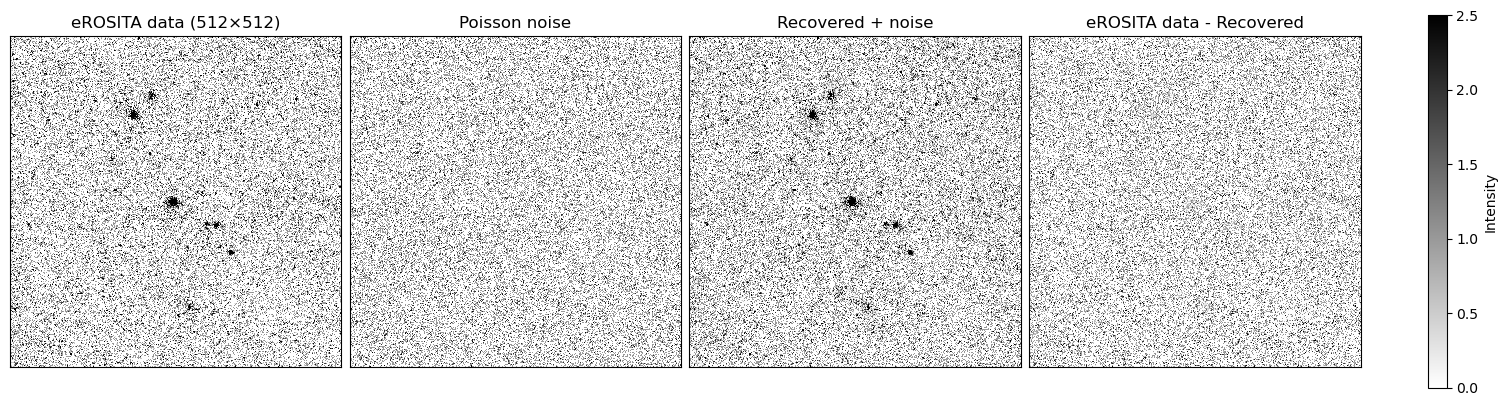

In [144]:
# ----
# Plot: data / noise / recovered with the same colorbar
# ----

# Visualization filters
GAUSS_SIGMA = 1
if gaussian_filter is None:
    raise ImportError('scipy is required for gaussian_filter in plot_XRAY.ipynb')

recovered_plot = gaussian_filter(recovered, sigma=GAUSS_SIGMA)

# Filter recovered map above the (1D) Nyquist frequency (cycles/pixel = 0.5).
# Uses a cosine taper to avoid sharp-cut ringing artifacts.
def _nyquist_taper_mask(h: int, w: int, frac: float = 0.9) -> np.ndarray:
    fx = np.fft.fftfreq(w, d=1.0)
    fy = np.fft.fftfreq(h, d=1.0)
    FY, FX = np.meshgrid(fy, fx, indexing='ij')
    k = np.sqrt(FX**2 + FY**2)
    k_nyq = 0.5
    k0 = float(frac) * k_nyq
    m = np.zeros((h, w), dtype=np.float64)
    m[k <= k0] = 1.0
    mid = (k > k0) & (k < k_nyq)
    if np.any(mid):
        m[mid] = 0.5 * (1.0 + np.cos(np.pi * (k[mid] - k0) / (k_nyq - k0)))
    return m

# _nyq_mask = _nyquist_taper_mask(recovered_plot.shape[0], recovered_plot.shape[1], frac=1.)
# recovered_plot = np.fft.ifft2(np.fft.fft2(recovered_plot) * _nyq_mask).real


cmap = cmocean.cm.balance
cmap = 'grey_r'


to_plot = [
    (data, f'eROSITA data ({MAP_SIZE}×{MAP_SIZE})'),
    (noise, f'Poisson noise'),
    (recovered + noise, f'Recovered + noise'),
    (data - recovered, f'eROSITA data - Recovered'),
]

vals = np.concatenate([np.ravel(a) for a, _ in to_plot]).astype(np.float64)
# vmin, vmax = np.percentile(vals, [1, 99])
vmin, vmax = 0, 2.5

norm = plt.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(1, 4, figsize=(15, 4), constrained_layout=True)
for ax, (arr, title) in zip(axes, to_plot):
    im = ax.imshow(arr, cmap=cmap, norm=norm, interpolation='nearest')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

cbar = fig.colorbar(im, ax=axes, shrink=0.95)
cbar.set_label('Intensity')
plt.savefig(ROOT / 'results_new' / f'comparison.png', dpi=150)
plt.show()


In [145]:
# nifty_posterior = np.load(ROOT / 'XRAY_results/xray_signal_samples.npy', allow_pickle=True)
# arr = nifty_posterior[4]

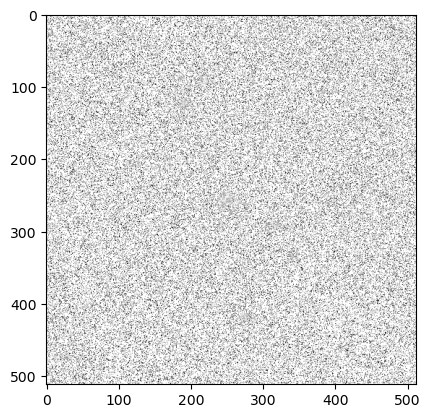

In [146]:
plt.imshow(data-recovered, cmap='grey_r', vmin=vmin, vmax=vmax)

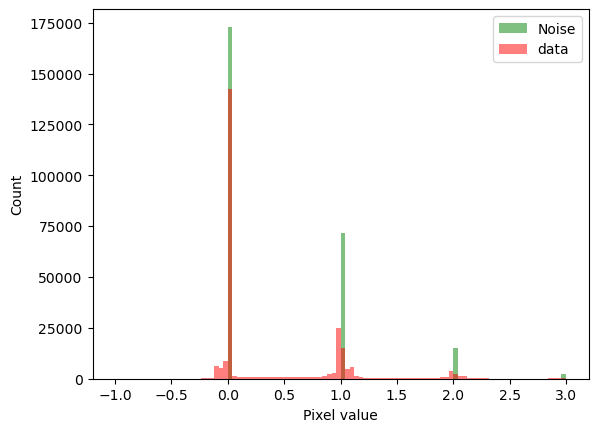

In [147]:
maxv = 3.0
rec = arr
plt.hist(noise.ravel(), bins=100, range=(-1, maxv), alpha=0.5, label="Noise", color="g")
# plt.hist((data - rec).ravel(), bins=100, range=(-1, maxv), alpha=0.5, label="Data-Nifty", color="r")
# plt.hist((data - recovered).ravel(), bins=100, range=(-1, maxv), alpha=0.5, label="Data-Scattering", color="b")

plt.hist(data.ravel(), bins=100, range=(-1, maxv), alpha=0.5, label="data", color="r")
# plt.hist((rec).ravel(), bins=100, range=(-1, maxv), alpha=0.5, label="recovered", color="g")

plt.legend()
plt.xlabel("Pixel value")
plt.ylabel("Count")
plt.savefig(ROOT / 'results_new' / f'histogram.png', dpi=150)


/var/folders/7v/7hfv67116xdb9qv3t1yztbsh0000gp/T/ipykernel_75042/2626172545.py:143: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, which='both', alpha=0.25)


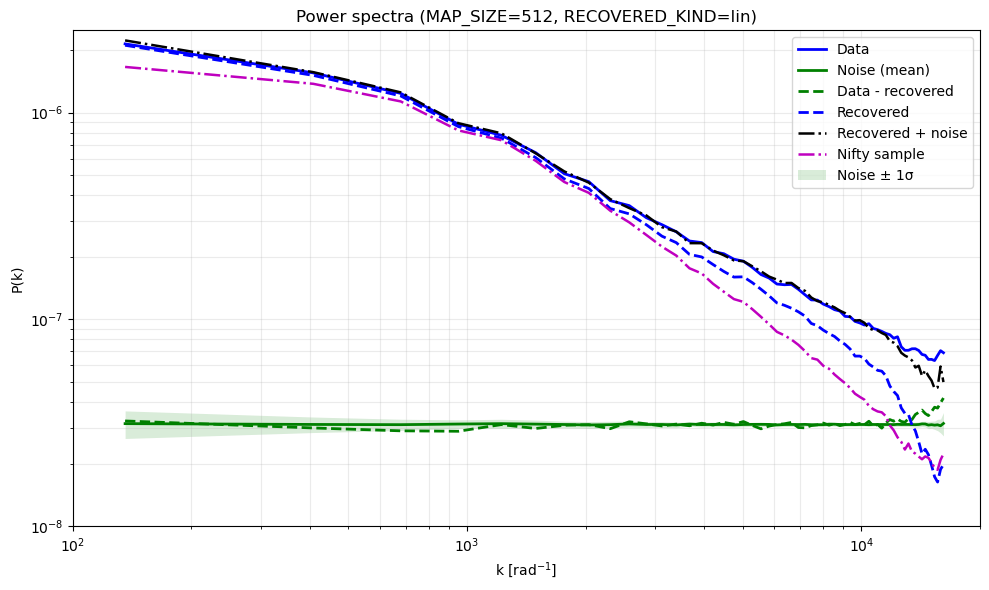

PosixPath('/Users/tsouros/Desktop/Projects/STL-Dev/X-ray project/results_new/power_spectra.png')

In [148]:
# ----
# Power spectra (flat-sky)
# Plot 1 (log-log): data, noise (mean +/- 1σ from 100 noise maps), residual, recovered, recovered+noise
# Plot 2 (linear): |cross spectrum| between data and residual
# Taking inspiration from plot.ipynb
# Colors requested (plot 1):
#   data: blue-
#   noise: green- (with ±1σ envelope)
#   data - recovered: green--
#   recovered: blue--
# (Recovered + noise is shown in black-.)
# ----

try:
    from scipy import stats
    from scipy.signal.windows import tukey
except Exception as exc:
    raise ImportError('scipy is required for power spectrum plotting') from exc

PATCH_SIZE_DEG = 8.0
ELL_BINS = 60
TUKEY_ALPHA = 0.25

npix = int(MAP_SIZE)
ps_rad = np.radians(PATCH_SIZE_DEG)
delta_theta = ps_rad / npix

window_1d = tukey(npix, TUKEY_ALPHA)
window_2d = np.outer(window_1d, window_1d)


def _prep(a: np.ndarray) -> np.ndarray:
    m = np.asarray(a, dtype=np.float64)
    m = m - np.mean(m)
    return m * window_2d


def _bin_radial(ps2d: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    kx = np.fft.fftfreq(npix, d=delta_theta)
    ky = np.fft.fftfreq(npix, d=delta_theta)
    kxx, kyy = np.meshgrid(kx, ky)

    # Flat-sky radial wavenumber (angular): k = 2π f, with f in cycles/radian.
    k = (2 * np.pi * np.sqrt(kxx**2 + kyy**2)).flatten()
    ps1d = np.asarray(ps2d, dtype=np.float64).flatten()

    k_bins = np.linspace(0, np.max(k), ELL_BINS + 1)
    pk_flat, _, _ = stats.binned_statistic(k, ps1d, bins=k_bins, statistic='mean')
    k_centers = 0.5 * (k_bins[1:] + k_bins[:-1])

    pk_flat = pk_flat / np.mean(window_2d**2)
    return pk_flat, k_centers


def powers_auto(a: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    m = _prep(a)
    fft_m = np.fft.fft2(m, norm=None)
    ps2d = np.abs(fft_m * np.conj(fft_m)) * (delta_theta**2) / (npix**2)
    return _bin_radial(ps2d)


def powers_cross_abs(a: np.ndarray, b: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    ma = _prep(a)
    mb = _prep(b)
    fft_a = np.fft.fft2(ma, norm=None)
    fft_b = np.fft.fft2(mb, norm=None)

    # Cross spectrum (complex); we plot the magnitude.
    cross2d = fft_a * np.conj(fft_b)
    ps2d = np.abs(cross2d) * (delta_theta**2) / (npix**2)
    return _bin_radial(ps2d)


residual = data - recovered
recovered_plus_noise = recovered + noise

# Auto spectra for main curves
pk_data, k = powers_auto(data)
pk_resid, _ = powers_auto(residual)
pk_rec, _ = powers_auto(recovered)
pk_rec_noise, _ = powers_auto(recovered_plus_noise)
pk_nifty, _ = powers_auto(nifty_posterior[4])

# Noise envelope from ALL noise maps (100 realizations)
noise_dir = ROOT / 'x-ray data' / str(MAP_SIZE_RAW)
noise_files = sorted(noise_dir.glob(f'poisson_image_{MAP_SIZE_RAW}_*.npy'))
if not noise_files:
    raise FileNotFoundError(f'No noise files found in {noise_dir}')

pk_noise_all = []
for nf in noise_files:
    n = np.load(nf)
    n = np.asarray(n).squeeze()
    if n.shape != TARGET_SHAPE:
        try:
            n = downsample_to_shape(n, TARGET_SHAPE, sigma=DOWNSAMPLE_SIGMA)
        except Exception:
            continue
    pk_n, _ = powers_auto(n)
    pk_noise_all.append(pk_n)

pk_noise_all = np.asarray(pk_noise_all, dtype=np.float64)
if pk_noise_all.ndim != 2 or pk_noise_all.shape[0] < 2:
    raise RuntimeError(f'Expected multiple noise spectra, got shape {pk_noise_all.shape}')

pk_noise_mean = np.nanmean(pk_noise_all, axis=0)
pk_noise_std = np.nanstd(pk_noise_all, axis=0)

# -----------------
# Plot 1: log-log
# -----------------

plt.figure(figsize=(10, 6))

def _mask_and_plot(kk, pp, style, label, lw=2):
    kk = np.asarray(kk)
    pp = np.asarray(pp)
    m = np.isfinite(kk) & (kk > 0) & np.isfinite(pp) & (pp > 0)
    plt.plot(kk[m], pp[m], style, linewidth=lw, label=label)

_mask_and_plot(k, pk_data, 'b-', 'Data', lw=2)
_mask_and_plot(k, pk_noise_mean, 'g-', 'Noise (mean)', lw=2)
_mask_and_plot(k, pk_resid, 'g--', 'Data - recovered', lw=2)
_mask_and_plot(k, pk_rec, 'b--', 'Recovered', lw=2)
_mask_and_plot(k, pk_rec_noise, 'k-.', 'Recovered + noise', lw=1.8)
_mask_and_plot(k, pk_nifty, 'm-.', 'Nifty sample', lw=1.8)


# ±1σ envelope for noise fluctuations
k_arr = np.asarray(k)
lo = np.maximum(pk_noise_mean - pk_noise_std, 1e-300)
hi = np.maximum(pk_noise_mean + pk_noise_std, 1e-300)
mask_env = np.isfinite(k_arr) & (k_arr > 0) & np.isfinite(lo) & np.isfinite(hi)
plt.fill_between(k_arr[mask_env], lo[mask_env], hi[mask_env], color='g', alpha=0.15, linewidth=0, label='Noise ± 1σ')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('k [rad$^{-1}$]')
plt.ylabel('P(k)')
plt.ylim(1e-8, 2.5e-6)
plt.xlim(1e2, 2e4)
plt.title(f'Power spectra (MAP_SIZE={MAP_SIZE}, RECOVERED_KIND={RECOVERED_KIND})')
plt.grid(False, which='both', alpha=0.25)
plt.legend()
plt.tight_layout()

out_dir = ROOT / 'results_new'
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / f'power_spectra.png'
plt.savefig(out_path, dpi=250)
plt.show()

out_path


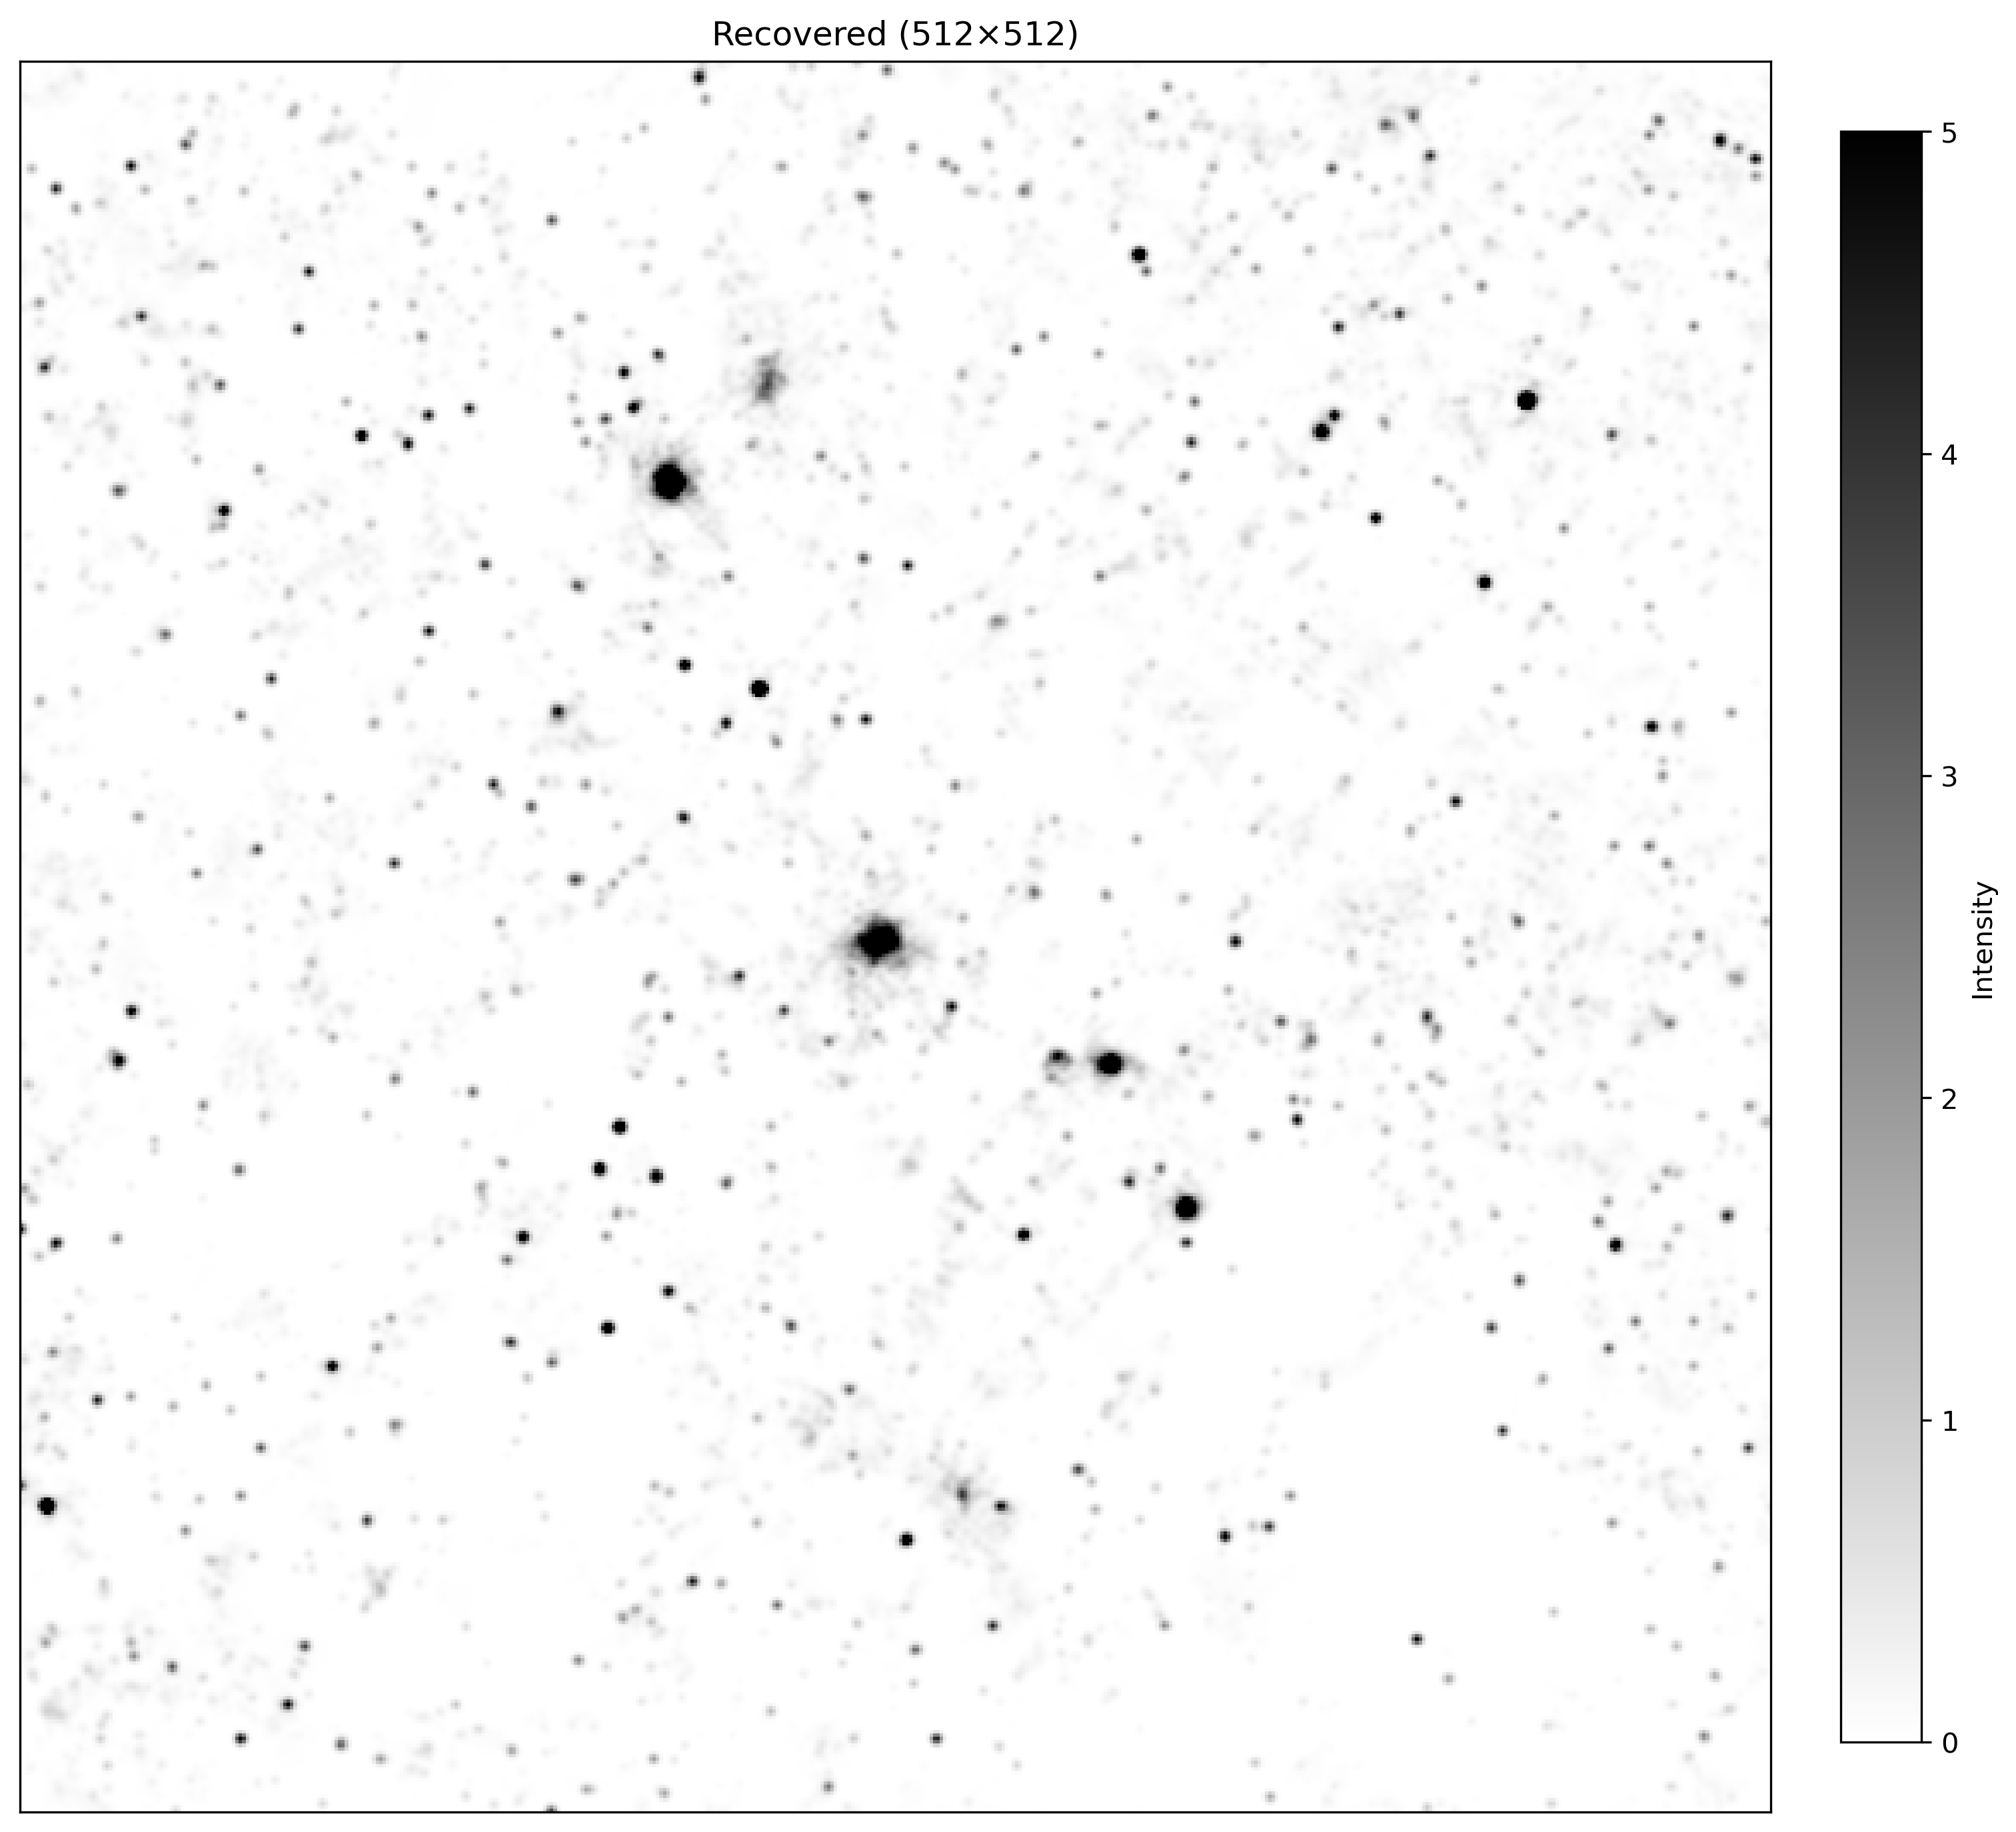

PosixPath('/Users/tsouros/Desktop/Projects/STL-Dev/X-ray project/results_new/highres_recovered_plot_512_recovered_signal_XRays_size512_dcfft_wtypeBump-Steerable_lpos10_lnoise0_mstep1_batch25_micro10_optNyq0_postNyq0.png')

In [149]:
# ----
# High-resolution single-map plot (saved)
# ----

HIGHRES_TARGET = "recovered"  # "recovered" | "data" | "noise" | "nifty"

if HIGHRES_TARGET == "recovered":
    arr = recovered
    title = f"Recovered ({MAP_SIZE}×{MAP_SIZE})"
    name_tag = "recovered_plot"
elif HIGHRES_TARGET == "data":
    arr = data
    title = f"eROSITA data ({MAP_SIZE}×{MAP_SIZE})"
    name_tag = "data"
elif HIGHRES_TARGET == "noise":
    arr = noise
    title = f"Poisson noise ({MAP_SIZE}×{MAP_SIZE})"
    name_tag = "noise"
elif HIGHRES_TARGET == "nifty":
    nifty_posterior = np.load(ROOT / "results_new/xray_signal_samples.npy", allow_pickle=True)
    arr = np.log(nifty_posterior[15] + 1.)
    title = f"Nifty sample ({MAP_SIZE}×{MAP_SIZE})"
    name_tag = "nifty"
else:
    raise ValueError(f"Unknown HIGHRES_TARGET={HIGHRES_TARGET!r}")

vmin, vmax = 0, 2.5
cmap = "grey_r"

fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=300, constrained_layout=True)
# im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
im = ax.imshow(recovered_plot, cmap=cmap, vmin = 0, vmax = 5, interpolation="nearest")

ax.set_title(title)
ax.set_xticks([])
ax.set_yticks([])
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Intensity")

out_dir = ROOT / "results_new"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / f"highres_{name_tag}_{MAP_SIZE}_{filename}.png"
fig.savefig(out_path, dpi=300)
plt.show()

out_path



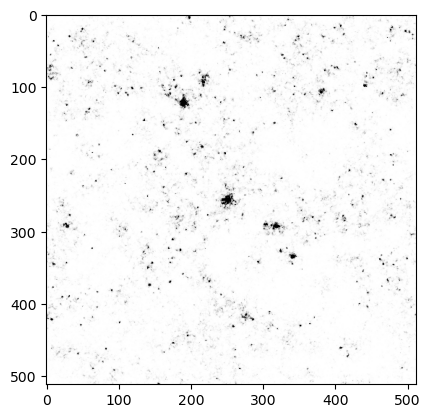

In [150]:
plt.imshow(nifty_posterior[0], cmap='grey_r', vmin=vmin, vmax=vmax)

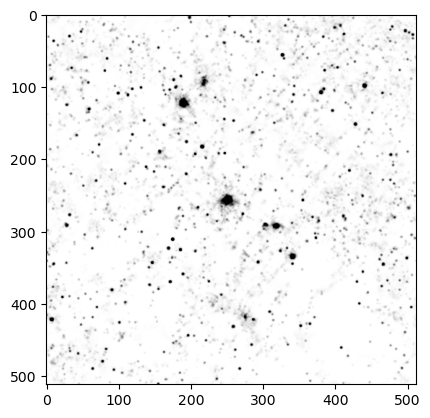

In [151]:
plt.imshow(recovered_plot, cmap='grey_r', vmin=vmin, vmax=vmax)

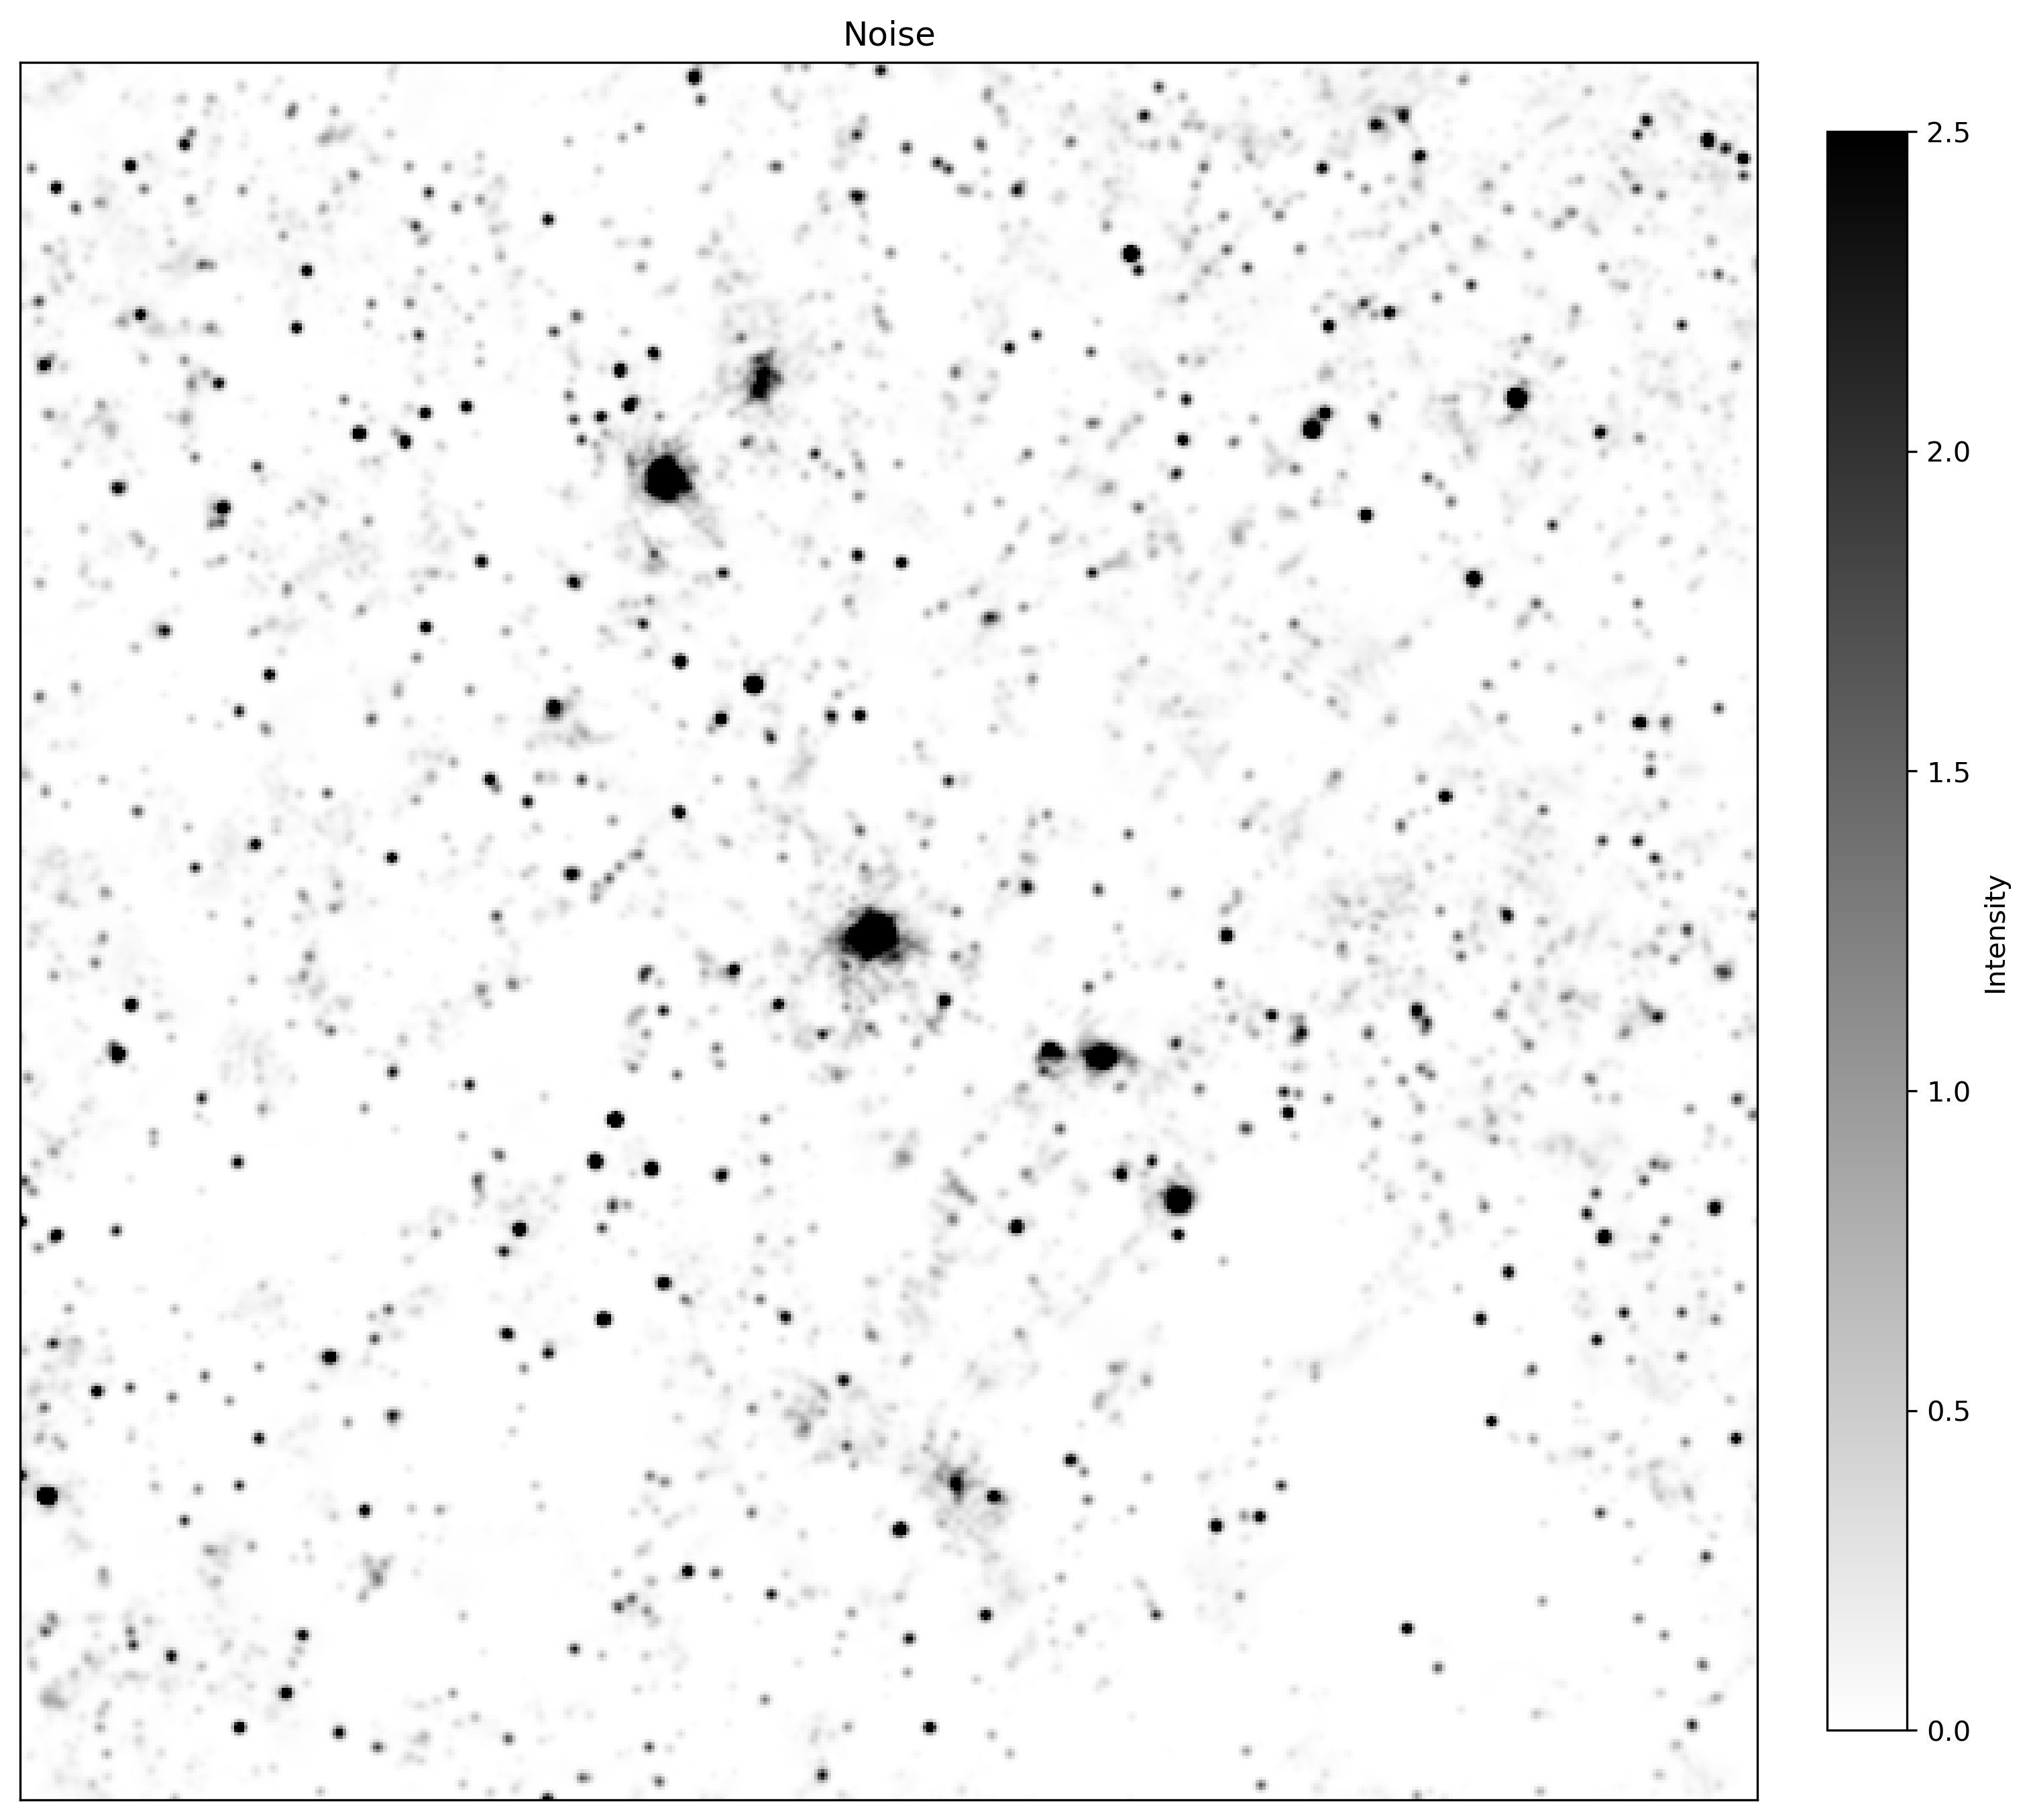

PosixPath('/Users/tsouros/Desktop/Projects/STL-Dev/X-ray project/results_new/STL_512_Noise.png')

In [154]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=300, constrained_layout=True)
im = ax.imshow(recovered_plot, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
cmap = 'grey_r'
# title = 'Noise'
# im = ax.imshow(data, cmap=cmap, vmin = 0, vmax = 1, interpolation="nearest", origin = 'lower')
# im = ax.imshow(np.std(nifty_posterior, axis=0), cmap=cmap, vmin = 0, vmax = 1, interpolation="nearest", origin = 'lower')
# im = ax.imshow(noise, cmap=cmap, vmin = 0, vmax = 5, interpolation="nearest", origin = 'lower')
# im = ax.imshow(nifty_posterior[4], cmap=cmap, vmin = 0, vmax = 5, interpolation="nearest", origin = 'lower')


# im = ax.imshow(data, cmap=cmap, vmin = 0, vmax = 5, interpolation="nearest")

ax.set_title(title)
ax.set_xticks([])
ax.set_yticks([])
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Intensity")

out_dir = ROOT / "results_new"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / f"STL_{MAP_SIZE}_Noise.png"
fig.savefig(out_path, dpi=300)
plt.show()

out_path
